# 08 · Pu.1 by lesion proximity: per animal / spinal level, and per cell vs composition

Follow-up to notebook 07, which found Pu.1⁺ cells near lesions (rim > peri > core > deep) carrying more
Pu.1 than distal Pu.1⁺ cells of the same section. Two questions:

1. **Is it everywhere?** The same paired comparison for every section on both replicate slides, grouped by
   animal (`P2_3`, `P3_1`, `R1_2`, `R1_3`) and spinal level (C cervical, T thoracic, L lumbar).
2. **More Pu.1 per cell, or a different mix of cells?** Pu.1⁺ cells are split into data-driven types
   (Gaussian mixture on Iba1 level, nuclear area and eccentricity), then (a) the mix of types is compared
   between compartments and (b) the comparison is repeated *within* each type. A decomposition splits
   the compartment-vs-distal difference into a composition part and a per-cell part.

Values are log2(section median / same section's distal Pu.1⁺ median) unless stated; with 8 sections the
tests are descriptive (min Wilcoxon p = 0.008, not corrected for multiple comparisons).

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
%config InlineBackend.figure_format = 'jpeg'   # image-heavy notebooks: keep files small
plt.rcParams["figure.dpi"] = 80
from lesionseg import report as R
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)
RUN_DIR = "outputs/sdata"
runs = R.load_runs(RUN_DIR)
print("scenes:", [r.name for r in runs])

from lesionseg import expression as E
df = E.expression_table(runs)
eff_pu1 = E.section_effects(df, "Pu1_mean")
eff_iba = E.section_effects(df, "Iba1_mean")
print(f"{len(eff_pu1)} slide × section combinations in lesion sections")

scenes: ['CML_1 scene 0', 'CML_2_rescan scene 0', 'CML_metal scene 0', 'CML_metal scene 1']


16 slide × section combinations in lesion sections


## 1 · Per section, slide, animal and level

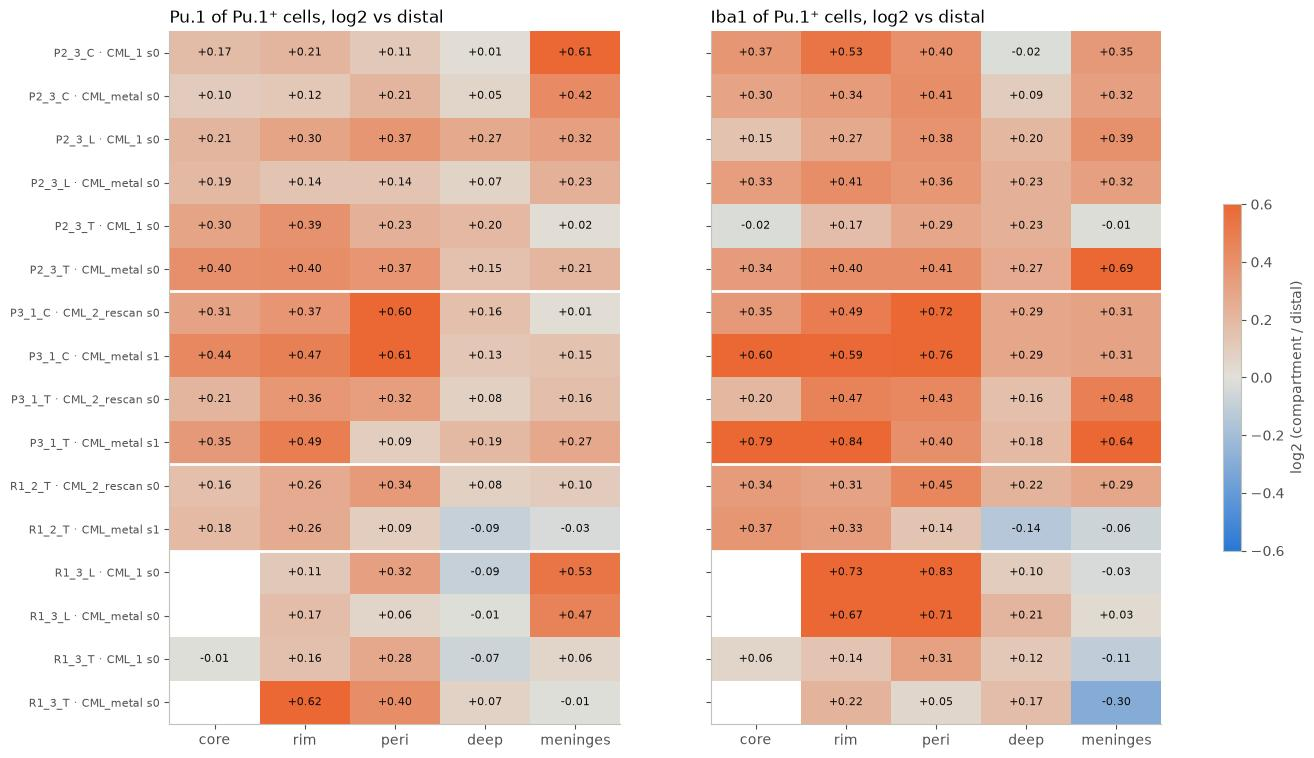

Rim above distal in **16 of 16** slide × section combinations; peri 16 of 16; core 12 of 13.

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
im = E.plot_effect_heatmap(eff_pu1, axes[0], "Pu.1 of Pu.1⁺ cells, log2 vs distal")
E.plot_effect_heatmap(eff_iba, axes[1], "Iba1 of Pu.1⁺ cells, log2 vs distal", row_labels=False)
fig.colorbar(im, ax=axes, shrink=0.5, label="log2 (compartment / distal)")
plt.show()
display(Markdown(f"Rim above distal in **{int((eff_pu1.rim > 0).sum())} of {int(eff_pu1.rim.notna().sum())}** slide × section "
                 f"combinations; peri {int((eff_pu1.peri > 0).sum())} of {int(eff_pu1.peri.notna().sum())}; "
                 f"core {int((eff_pu1.core > 0).sum())} of {int(eff_pu1.core.notna().sum())}."))

### By spinal level and animal (each dot = one section on one slide)

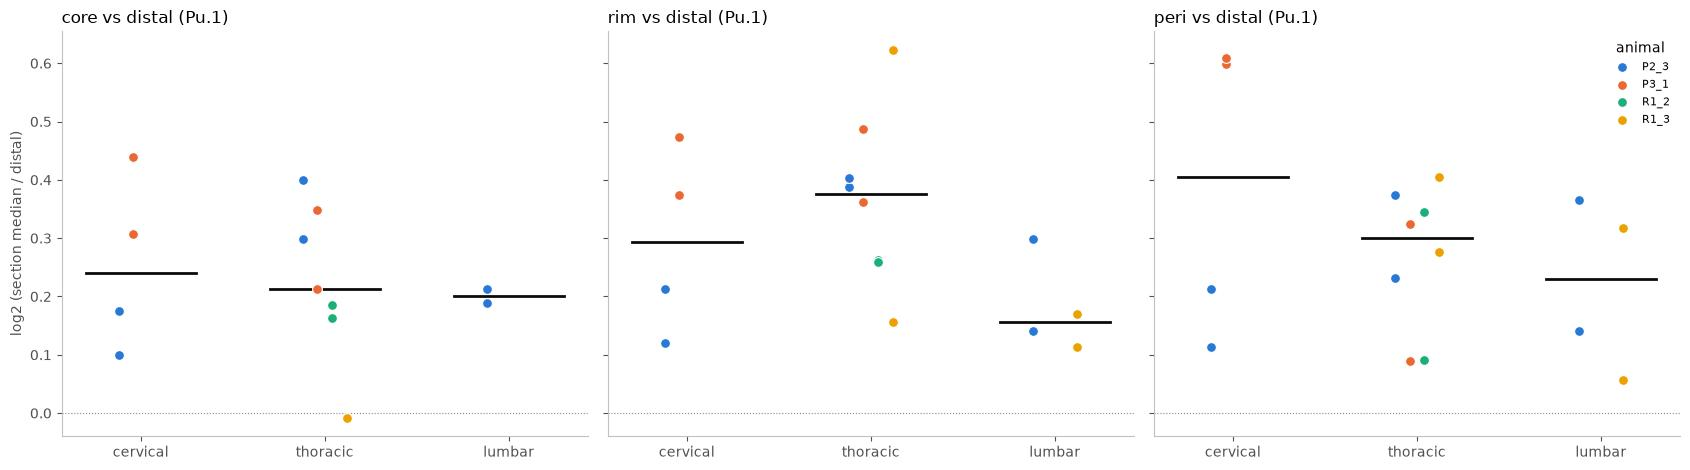

,core,rim,peri,deep,meninges
level,,,,,
C,0.24,0.29,0.41,0.09,0.28
T,0.21,0.37,0.30,0.08,0.08
L,0.20,0.16,0.23,0.03,0.39


,core,rim,peri,deep,meninges
animal,,,,,
P2_3,0.20,0.26,0.22,0.11,0.27
P3_1,0.33,0.42,0.46,0.15,0.16
R1_2,0.17,0.26,0.22,-0.01,0.04
R1_3,-0.01,0.16,0.30,-0.04,0.26


In [3]:
levels = ["C", "T", "L"]
animals = sorted(eff_pu1.animal.unique())
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, comp in zip(axes, ["core", "rim", "peri"]):
    for k, (an, col) in enumerate(zip(animals, E.SCENE_COLORS)):
        d = eff_pu1[eff_pu1.animal == an]
        x = d.level.map({l: i for i, l in enumerate(levels)}) + (k - 1.5) * 0.08
        ax.scatter(x, d[comp], s=50, color=col, edgecolors="white", linewidths=0.8, label=an, zorder=3)
    for i, l in enumerate(levels):
        v = eff_pu1.loc[eff_pu1.level == l, comp].dropna()
        if len(v):
            ax.plot([i - 0.3, i + 0.3], [v.median()] * 2, color="#0b0b0b", lw=2)
    ax.axhline(0, color="#898781", lw=0.8, ls=":")
    ax.set_xticks(range(3), ["cervical", "thoracic", "lumbar"]); ax.set_title(f"{comp} vs distal (Pu.1)", loc="left")
axes[0].set_ylabel("log2 (section median / distal)"); axes[-1].legend(fontsize=8, frameon=False, title="animal")
plt.tight_layout(); plt.show()
display(eff_pu1.groupby("level")[["core", "rim", "peri", "deep", "meninges"]].median().reindex(levels).round(2))
display(eff_pu1.groupby("animal")[["core", "rim", "peri", "deep", "meninges"]].median().round(2))

### Replicate slides agree?

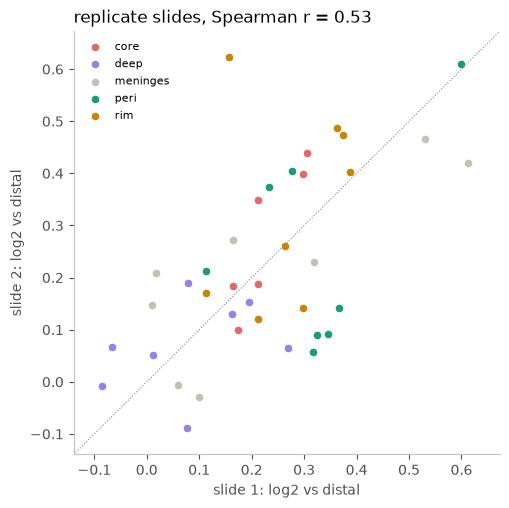

In [4]:
long = eff_pu1.melt(id_vars=["scene", "section"], value_vars=["core", "rim", "peri", "deep", "meninges"],
                    var_name="compartment", value_name="log2").dropna()
long["slide"] = long.groupby(["section", "compartment"]).cumcount()
pairs = long.pivot_table(index=["section", "compartment"], columns="slide", values="log2").dropna()
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for comp, d in pairs.groupby(level="compartment"):
    ax.scatter(d[0], d[1], s=40, color=E.COLORS[comp], edgecolors="white", linewidths=0.8, label=comp)
lim = [min(pairs.min().min(), 0) - 0.05, pairs.max().max() + 0.05]
ax.plot(lim, lim, color="#898781", lw=0.8, ls=":"); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("slide 1: log2 vs distal"); ax.set_ylabel("slide 2: log2 vs distal")
ax.set_title(f"replicate slides, Spearman r = {pairs[0].corr(pairs[1], method='spearman'):.2f}", loc="left")
ax.legend(fontsize=8, frameon=False); plt.show()

### Gradient per animal and per level (slides pooled; Pu.1 relative to each slide's control level)

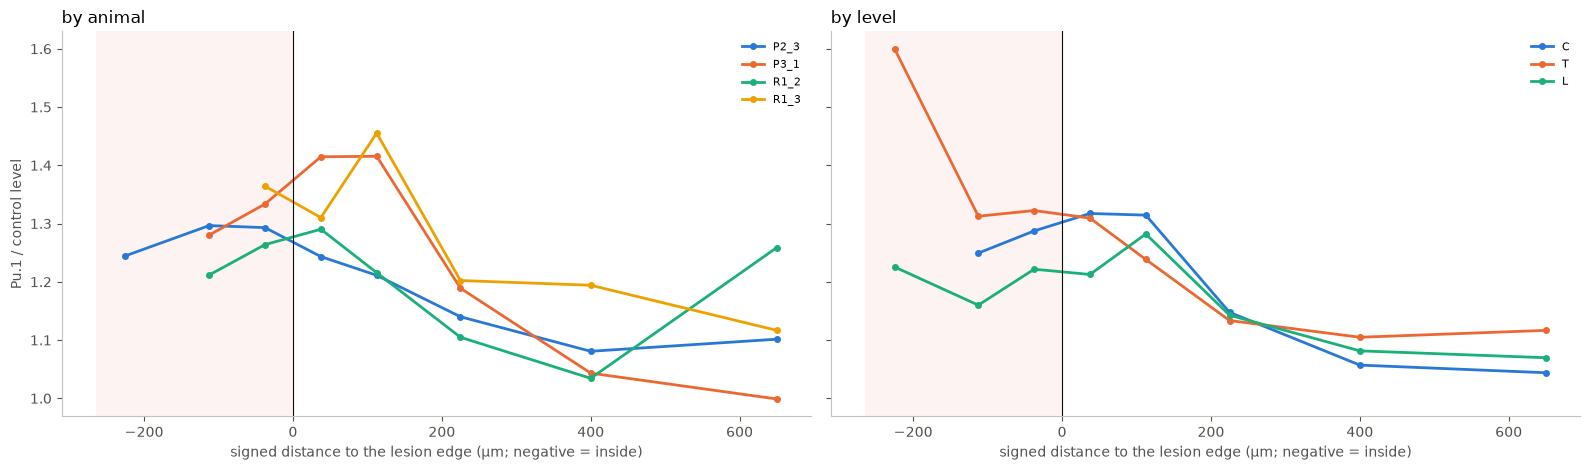

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharey=True)
for ax, by, order in ((axes[0], "animal", animals), (axes[1], "level", levels)):
    g = E.gradient_by(df, "Pu1_mean_norm", by)
    for key, col in zip(order, E.SCENE_COLORS):
        d = g[g[by] == key].sort_values("mid_um")
        ax.plot(d.mid_um, d["median"], color=col, lw=2, marker="o", ms=4, label=key)
    ax.axvline(0, color="#0b0b0b", lw=0.8); ax.axvspan(g.mid_um.min() - 40, 0, color="#e66767", alpha=0.08, lw=0)
    ax.set_xlabel("signed distance to the lesion edge (µm; negative = inside)"); ax.set_title(f"by {by}", loc="left")
    ax.legend(fontsize=8, frameon=False)
axes[0].set_ylabel("Pu.1 / control level")
plt.tight_layout(); plt.show()

## 2 · More Pu.1 per cell, or a different mix of cells?

Pu.1⁺ cells are split by a Gaussian mixture on log2 Iba1 (vs the slide's control level), log2 nuclear
area and eccentricity. BIC stops improving after three components; they are named from their means.
These are **morphological types, not validated cell identities** – the `small` type in particular may
partly be segmentation fragments.

,1,2,3,4,5
BIC,340686.0,334853.0,332615.0,332699.0,332589.0


,n,iba1_vs_control,area_um2,eccentricity,pu1_vs_control,share
cell_type,,,,,,
round,15500,1.34,33.19,0.52,1.23,0.28
elongated,27975,1.32,32.76,0.76,1.24,0.51
small,11405,1.16,12.26,0.68,1.04,0.21


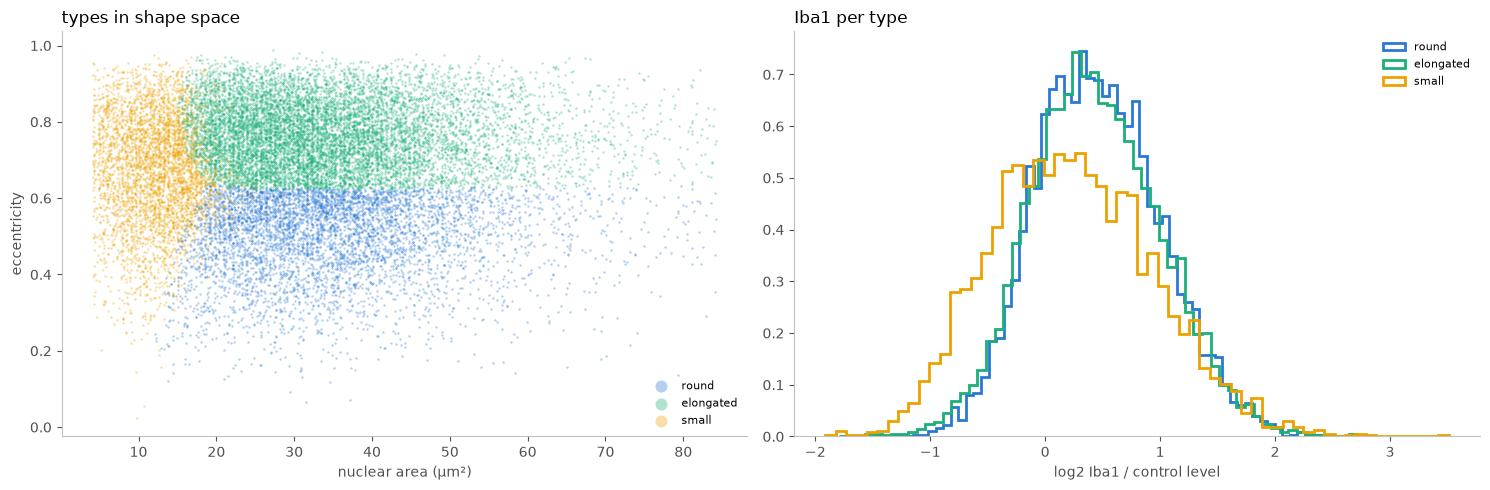

In [6]:
ct, prof, bic = E.cell_types(df)
display(bic.round(0).to_frame().T)
display(prof.round(2))
pos = ct[ct.cell_type.notna()].sample(20000, random_state=0)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for t in E.CELL_TYPE_ORDER:
    d = pos[pos.cell_type == t]
    axes[0].scatter(d.area_um2, d.eccentricity, s=3, alpha=0.35, color=E.CELL_TYPE_COLORS[t], linewidths=0, label=t)
    axes[1].hist(np.log2(d.Iba1_mean_norm.clip(lower=0.05)), bins=60, histtype="step", lw=2,
                 color=E.CELL_TYPE_COLORS[t], label=t, density=True)
axes[0].set_xlabel("nuclear area (µm²)"); axes[0].set_ylabel("eccentricity"); axes[0].set_title("types in shape space", loc="left")
axes[0].legend(markerscale=5, fontsize=8, frameon=False)
axes[1].set_xlabel("log2 Iba1 / control level"); axes[1].set_title("Iba1 per type", loc="left"); axes[1].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

### (a) The mix of types per compartment (median share over slide × section)

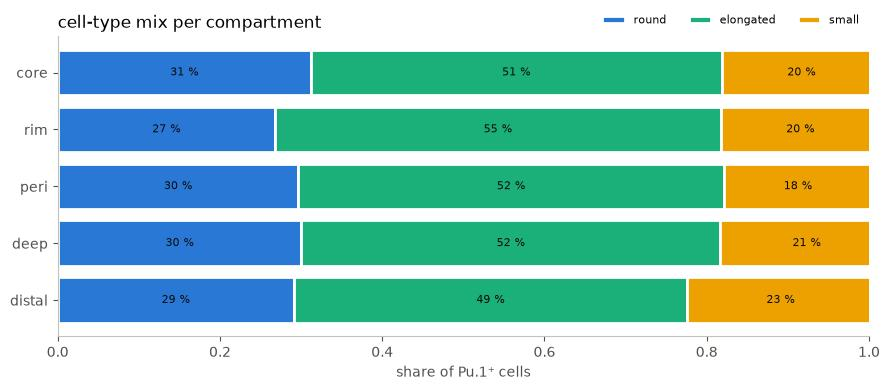

cell_type,round,elongated,small
compartment,,,
core,0.312,0.506,0.197
rim,0.268,0.550,0.196
peri,0.296,0.525,0.183
deep,0.300,0.516,0.213
distal,0.291,0.485,0.230


In [7]:
comp = E.composition(ct)
share = comp.groupby("compartment", observed=True)[E.CELL_TYPE_ORDER].median().reindex(E.LESION_ORDER)
fig, ax = plt.subplots(figsize=(9, 4))
left = np.zeros(len(share))
for t in E.CELL_TYPE_ORDER:
    ax.barh(share.index, share[t], left=left, color=E.CELL_TYPE_COLORS[t], edgecolor="white", linewidth=2, label=t)
    for i, (l, v) in enumerate(zip(left, share[t])):
        ax.text(l + v / 2, i, f"{100 * v:.0f} %", ha="center", va="center", fontsize=8, color="#0b0b0b")
    left += share[t].to_numpy()
ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel("share of Pu.1⁺ cells")
ax.legend(fontsize=8, frameon=False, ncol=3, loc="lower right", bbox_to_anchor=(1, 1))
ax.set_title("cell-type mix per compartment", loc="left"); plt.tight_layout(); plt.show()
display(share.round(3))

### (b) Pu.1 within each type, paired per section

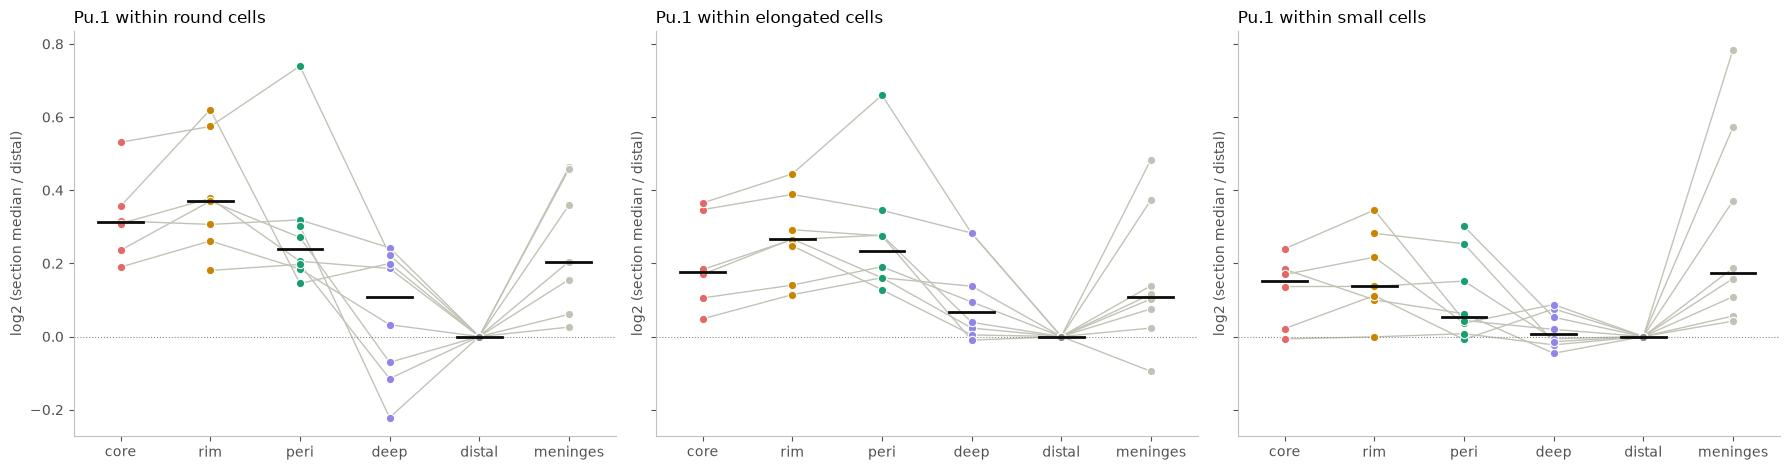

**round**

,compartment,n_sections,median_log2_vs_distal,fold_change,sections_higher,wilcoxon_p
0,core,6,0.3124,1.2417,6,0.0312
1,rim,7,0.3703,1.2926,7,0.0156
2,peri,8,0.2383,1.1796,8,0.0078
3,deep,8,0.1092,1.0786,5,0.3828
4,meninges,7,0.2047,1.1525,7,0.0156


**elongated**

,compartment,n_sections,median_log2_vs_distal,fold_change,sections_higher,wilcoxon_p
0,core,6,0.1767,1.1303,6,0.0312
1,rim,8,0.2659,1.2024,8,0.0078
2,peri,8,0.2331,1.1753,8,0.0078
3,deep,8,0.0667,1.0473,7,0.0234
4,meninges,8,0.1090,1.0785,7,0.0391


**small**

,compartment,n_sections,median_log2_vs_distal,fold_change,sections_higher,wilcoxon_p
0,core,6,0.1531,1.1120,5,0.0625
1,rim,7,0.1370,1.0996,6,0.0312
2,peri,8,0.0530,1.0374,7,0.0234
3,deep,8,0.0067,1.0047,4,0.4609
4,meninges,8,0.1728,1.1272,8,0.0078


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharey=True)
within = {}
for ax, t in zip(axes, E.CELL_TYPE_ORDER):
    med = E.section_medians(ct[ct.cell_type == t], "Pu1_mean", min_cells=15)
    E.plot_paired(med, ax, f"Pu.1 within {t} cells")
    within[t] = E.paired_tests(med)
plt.tight_layout(); plt.show()
for t, tab in within.items():
    display(Markdown(f"**{t}**")); display(tab.round(4))

### (c) Decomposition: how much of the difference is composition?

For each slide × section, the difference in *mean* Pu.1 between a compartment and distal is split into a
per-cell part (distal mix of types, compartment's per-type Pu.1) and a composition part (the rest).
`share_per_cell` ≈ 1 means the difference is per-cell expression, not a shift in which cells are there.

,observed,per_cell,composition,share_per_cell
compartment,,,,
core,0.225,0.219,0.012,0.972
rim,0.547,0.568,0.019,1.038
peri,0.472,0.499,0.023,1.059
deep,0.176,0.150,0.015,0.851


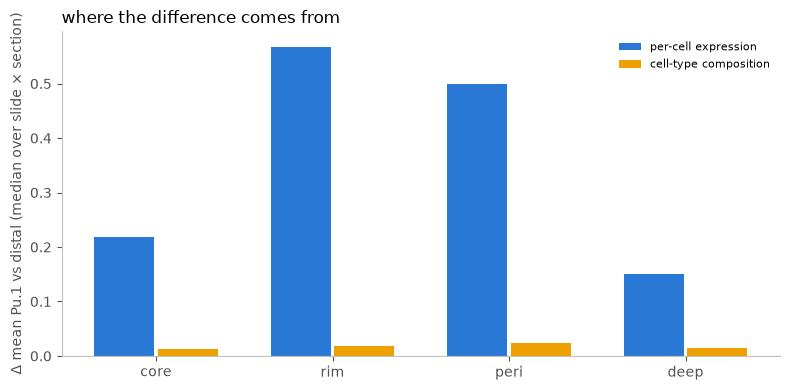

In [9]:
summ, per = E.composition_vs_expression(ct)
display(summ.round(3))
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(summ))
ax.bar(x - 0.18, summ.per_cell, width=0.34, color="#2a78d6", label="per-cell expression")
ax.bar(x + 0.18, summ.composition, width=0.34, color="#eda100", label="cell-type composition")
ax.axhline(0, color="#898781", lw=0.8)
ax.set_xticks(x, summ.index); ax.set_ylabel("Δ mean Pu.1 vs distal (median over slide × section)")
ax.set_title("where the difference comes from", loc="left"); ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## Reading

* If every animal and level shows the rim above distal, and both replicate slides agree, the edge effect
  is a property of the lesions, not of one animal, one level or one scan.
* If `share_per_cell` is close to 1 and Pu.1 rises *within* each type, the higher Pu.1 near lesions is
  more Pu.1 per cell – an activation signal – rather than a different cell population moving in.
  Morphological types are a coarse proxy; a resident-vs-infiltrating marker (TMEM119 / P2RY12 vs CCR2)
  or the DVP proteomes themselves would test this directly.